## Grokking — Delayed Generalization

Sometimes a neural network memorizes its training set perfectly and *then* — long
after the training loss has flat-lined near zero — it suddenly starts to
generalize: validation accuracy jumps from chance to ~100%. This delayed
generalization is called **grokking**, first reported by Power et al. (2022) on
small algorithmic datasets.

In this lab we reproduce grokking on a minimal setup: a tiny MLP learning
**modular addition**.

### Learning objectives
- Build the modular-addition dataset and a small embedding + MLP model.
- Implement a full-batch training loop and watch *memorization* (train acc → 100%)
  and *generalization* (val acc → 100%) as **separate events**.
- Use **weight decay** as the "grokking knob": tune it to switch between immediate
  generalization and delayed grokking.
- Measure the **grokking gap** — how many epochs separate memorization from
  generalization.
- Study how the **choice of optimizer** changes that gap.
  solution.

Inspiration: https://github.com/okitouni/simple-grokking

In [ ]:
import copy
import numpy as np
import torch
import torch.nn as nn
import tqdm
import matplotlib.pyplot as plt

torch.manual_seed(0)

True

### The modular-addition task

We learn the map $(a, b) \mapsto (a + b) \bmod p$ with $p = 53$ (a prime). The
inputs $a, b \in \{0, \dots, p-1\}$, so the full dataset has only $p^2 = 2809$
examples. We hold out a fraction of them for validation.

Because the task is a *finite lookup table*, a model with enough capacity can
simply **memorize** the training pairs without learning the underlying rule.
Grokking is the surprising event where, much later, the model discovers the
*rule* itself and so generalizes to the held-out pairs.

In [2]:
P = 53  # prime modulus for the task: target = (a + b) % P


def make_data(p: int = P, train_frac: float = 0.6, seed: int = 42):
    """Build the full (a, b) -> (a + b) % p dataset and split it into train/val."""
    torch.manual_seed(seed)
    X = torch.cartesian_prod(torch.arange(p), torch.arange(p))
    y = (X[:, 0] + X[:, 1]) % p
    shuffle = torch.randperm(len(X))
    X, y = X[shuffle], y[shuffle]
    n = int(train_frac * len(X))
    return X[:n], y[:n], X[n:], y[n:]


X_train, y_train, X_val, y_val = make_data()
print(f"train: {len(X_train)} examples | val: {len(X_val)} examples | classes: {P}")

train: 1685 examples | val: 1124 examples | classes: 53


### What does the data look like?

The whole task fits in a single picture. Every example is a pair $(a, b)$, so the
dataset is a $p \times p$ grid indexed by the two inputs, and each cell holds the
target $(a + b) \bmod p$. The plot below shows that grid (left) next to the
train/val split (right): the model only ever sees the scattered **train** cells
and must recover the smooth diagonal rule well enough to fill in the **held-out**
ones — which is exactly what grokking, when it eventually happens, achieves.

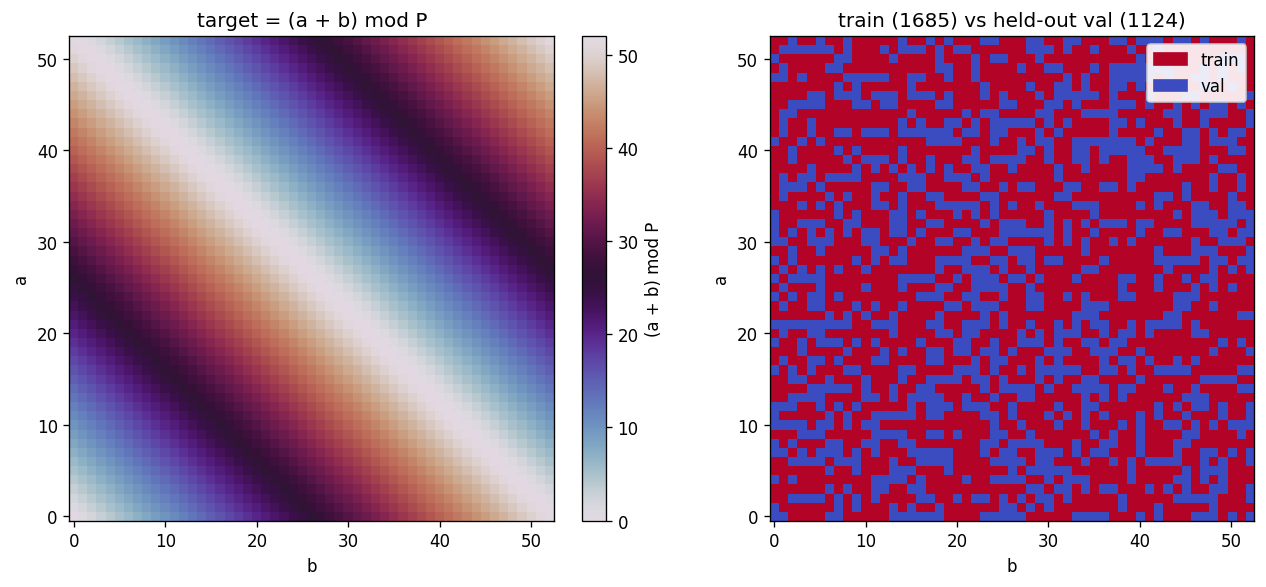

In [3]:
def plot_dataset(X_train, X_val, p=P):
    """Visualise the task as two p x p grids indexed by the inputs (a, b).

    Left:  the *full* lookup table the model must learn -- target = (a + b) % p.
           A cyclic colormap makes the wrap-around visible: the value increases
           along each anti-diagonal and jumps back to 0 when the sum passes p.
    Right: which (a, b) cells the model actually sees (train) vs. the ones held
           out for validation. The split is random, so generalising means
           recovering the diagonal rule on the left from a sparse sample.
    """
    from matplotlib.patches import Patch

    a = np.arange(p)
    table = (a[:, None] + a[None, :]) % p          # full ground-truth grid

    split = np.full((p, p), np.nan)                # 1 = train, 0 = val
    split[X_train[:, 0].numpy(), X_train[:, 1].numpy()] = 1
    split[X_val[:, 0].numpy(),   X_val[:, 1].numpy()]   = 0

    fig, ax = plt.subplots(1, 2, figsize=(11, 5), dpi=120)

    im = ax[0].imshow(table, cmap="twilight", origin="lower")
    ax[0].set_title("target = (a + b) mod P")
    ax[0].set_xlabel("b"); ax[0].set_ylabel("a")
    fig.colorbar(im, ax=ax[0], fraction=0.046, label="(a + b) mod P")

    ax[1].imshow(split, cmap="coolwarm", origin="lower", vmin=0, vmax=1)
    ax[1].set_title(f"train ({len(X_train)}) vs held-out val ({len(X_val)})")
    ax[1].set_xlabel("b"); ax[1].set_ylabel("a")
    ax[1].legend(
        handles=[Patch(color=plt.cm.coolwarm(1.0), label="train"),
                 Patch(color=plt.cm.coolwarm(0.0), label="val")],
        loc="upper right", framealpha=0.9,
    )
    fig.tight_layout()
    plt.show()


plot_dataset(X_train, X_val)

### The model

Each integer is mapped to a learnable **embedding** of dimension
`hidden_dim = 128`. The two embeddings (for $a$ and $b$) are concatenated and
passed through a 2-layer MLP that outputs logits over the $p$ possible sums:

$$\operatorname{emb}(a)\;\Vert\;\operatorname{emb}(b)
\;\xrightarrow{\;W_1,\ \mathrm{ReLU}\;}\; h
\;\xrightarrow{\;W_2\;}\; \text{logits}\in\mathbb{R}^{p}.$$

### Exercise 1 — the forward pass
Implement `Model.forward`:
1. Look up the embeddings of the input integers (`x` has shape `(batch, 2)`) and
   flatten the two embeddings into a single vector of size `2 * hidden_dim`.
2. Apply `fc1` followed by a ReLU.
3. Apply `readout` to obtain the logits.

In [4]:
class Model(nn.Module):
    def __init__(self, hidden_dim=128, p=P):
        super().__init__()
        self.embedding = nn.Embedding(p, hidden_dim)
        self.fc1 = nn.Linear(2 * hidden_dim, hidden_dim)
        self.readout = nn.Linear(hidden_dim, p)

    def forward(self, x):
        emb = self.embedding(x)
        emb = emb.view(emb.shape[0], -1)
        h = torch.relu(self.fc1(emb))
        logits = self.readout(h)
        return logits

In [28]:
logits = Model()(X_train[:4])
print(logits.shape)

torch.Size([4, 53])


### Training: memorization vs generalization

We train **full-batch** (the whole training set is one batch) with cross-entropy
loss. After every step we record train/val loss and accuracy. The two quantities
to watch are:
- **train accuracy** → reaches 100% quickly (the model *memorizes*).
- **val accuracy** → may stay near chance ($\approx 1/p$) for a long time, then
  jump to 100% (*grokking*).

### Exercise 2 — the optimization step
Fill in the single gradient step inside the loop: zero the gradients, forward
pass on the training batch, compute the cross-entropy loss, backward, optimizer
step. The metrics block below your code expects you to have defined the variables
`logits` and `loss`.

In [11]:
@torch.no_grad()
def evaluate(model, X, y, criterion):
    logits = model(X)
    loss = criterion(logits, y).item()
    acc = (logits.argmax(dim=1) == y).float().mean().item() * 100
    return loss, acc


def train_model(model, optimizer, data, num_epochs, progress=True):
    """Full-batch training loop. Returns a history dict of per-epoch metrics."""
    X_train, y_train, X_val, y_val = data
    criterion = nn.CrossEntropyLoss()
    history = {k: [] for k in ("epoch", "train_loss", "train_acc", "val_loss", "val_acc")}

    epochs = tqdm.trange(num_epochs) if progress else range(num_epochs)
    for epoch in epochs:
        # --- Exercise 2 ---
        optimizer.zero_grad()

        logits = model(X_train)
        loss = criterion(logits, y_train)

        loss.backward()
        optimizer.step()
        # --- End Exercise 2 ---

        with torch.no_grad():
            train_loss = loss.item()
            train_acc = (logits.argmax(dim=1) == y_train).float().mean().item() * 100
            val_loss, val_acc = evaluate(model, X_val, y_val, criterion)

        for k, v in zip(history, (epoch, train_loss, train_acc, val_loss, val_acc)):
            history[k].append(v)

    return history

`plot_history` draws train/val loss and accuracy against epochs. The epoch axis
is log-scaled (and we shift by +1 so epoch 0 is visible) — grokking spans orders
of magnitude in time, so a linear axis would hide it.

In [12]:
def plot_history(history, title=""):
    epochs = np.array(history["epoch"]) + 1  # +1 so epoch 0 shows on a log axis
    fig, ax = plt.subplots(2, 1, sharex=True, figsize=(7, 6), dpi=120)

    ax[0].plot(epochs, history["train_loss"], label="train")
    ax[0].plot(epochs, history["val_loss"], label="val")
    ax[0].set_ylabel("loss")
    ax[0].set_yscale("log")
    ax[0].legend()

    ax[1].plot(epochs, history["train_acc"], label="train")
    ax[1].plot(epochs, history["val_acc"], label="val")
    ax[1].set_ylabel("accuracy (%)")
    ax[1].set_xlabel("epoch")
    ax[1].axhline(100, color="gray", lw=0.5, ls=":")
    ax[1].legend()

    ax[0].set_xscale("log")
    if title:
        ax[0].set_title(title)
    fig.tight_layout()
    plt.show()

### Watch the model grok

Train with **AdamW**, a small weight decay (`3e-2`) and learning rate `3e-2`. On
the log-scaled epoch axis you should see train accuracy hit 100% early while val
accuracy lingers near chance, then snap up to 100% much later — the signature
grokking curve.

> Full-batch training for several thousand epochs takes ~1–3 minutes on CPU. The
> dataset and model are tiny, so each epoch is cheap; the epochs are just many.

100%|██████████| 8000/8000 [00:33<00:00, 239.55it/s]


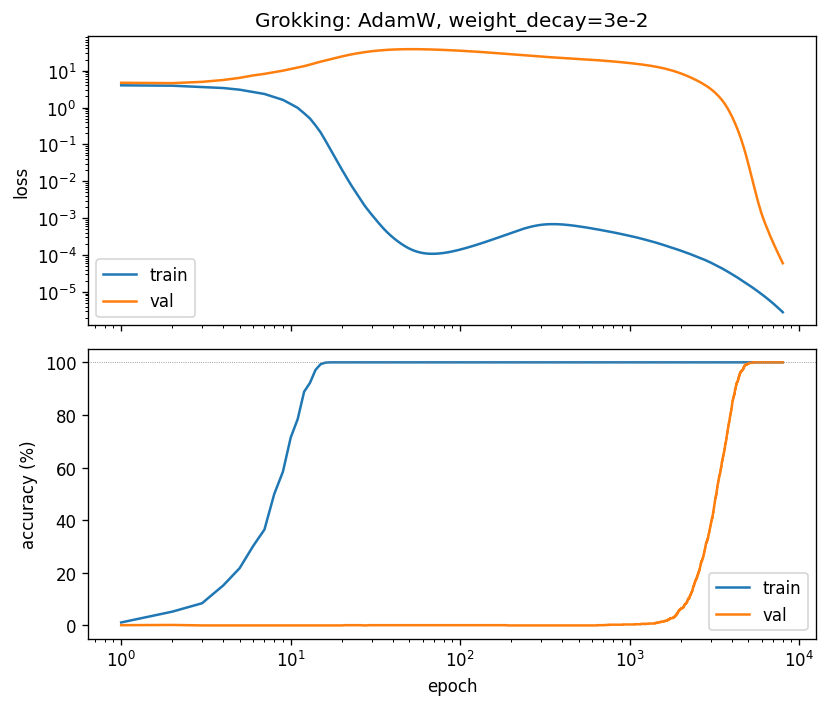

In [13]:
NUM_EPOCHS = 8000
data = make_data()

torch.manual_seed(0)
grok_model = Model(hidden_dim=128)
grok_opt = torch.optim.AdamW(grok_model.parameters(), lr=3e-2, weight_decay=3e-2)
grok_history = train_model(grok_model, grok_opt, data, NUM_EPOCHS)
plot_history(grok_history, title="Grokking: AdamW, weight_decay=3e-2")

Na wykresie widać charakterystyczny przebieg **grokkingu**. Model bardzo szybko uczy się zbioru treningowego: dokładność treningowa osiąga prawie **100%** już po kilkunastu epokach, a strata treningowa spada niemal do zera. Oznacza to, że sieć skutecznie **zapamiętała** przykłady treningowe.

Jednocześnie dokładność walidacyjna przez długi czas pozostaje bliska zeru, czyli model mimo idealnego dopasowania do treningu nie potrafi jeszcze poprawnie przewidywać wyników dla niewidzianych par `(a, b)`. Strata walidacyjna początkowo nawet rośnie, co pokazuje, że model staje się bardzo pewny swoich błędnych predykcji na zbiorze walidacyjnym.

Dopiero po wielu epokach następuje gwałtowny skok dokładności walidacyjnej do prawie **100%**. Jest to moment, w którym model przechodzi od prostego zapamiętania danych do nauczenia się ogólnej reguły:

\[
(a + b) \bmod P
\]

Różnica czasu między osiągnięciem wysokiej dokładności treningowej a wysokiej dokładności walidacyjnej to właśnie **grokking gap**. W tym eksperymencie model najpierw memoruje dane, a dopiero dużo później zaczyna generalizować.

### Exercise 3 — comprehension vs grokking
Train the **same** model/optimizer setup but with a *large* weight decay
(`weight_decay=5`). Plot the curve and compare it with Experiment 1.

Then answer:
- How does the train/val accuracy gap over epochs differ between `wd=3e-2` and
  `wd=5`?
- Why does *stronger* weight decay *remove* the grokking delay?
- What happens with `weight_decay=0`? Try it.

100%|██████████| 8000/8000 [00:39<00:00, 204.70it/s]


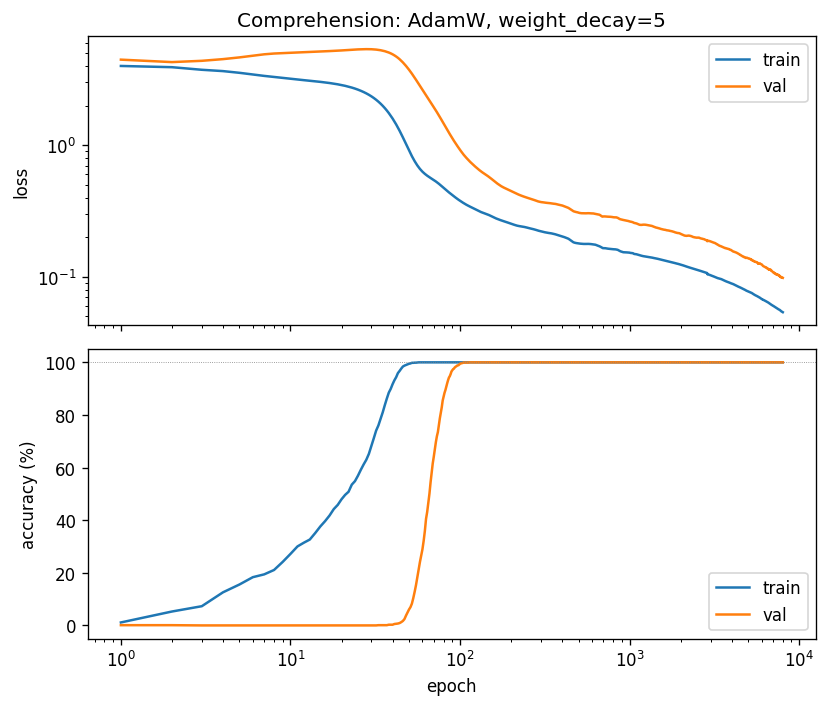

In [14]:
NUM_EPOCHS = 8000
data = make_data()

torch.manual_seed(0)
strong_wd_model = Model(hidden_dim=128)
strong_wd_opt = torch.optim.AdamW(
    strong_wd_model.parameters(),
    lr=3e-2,
    weight_decay=5,
)

strong_wd_history = train_model(
    strong_wd_model,
    strong_wd_opt,
    data,
    NUM_EPOCHS,
)

plot_history(strong_wd_history, title="Comprehension: AdamW, weight_decay=5")

100%|██████████| 8000/8000 [00:34<00:00, 229.55it/s]


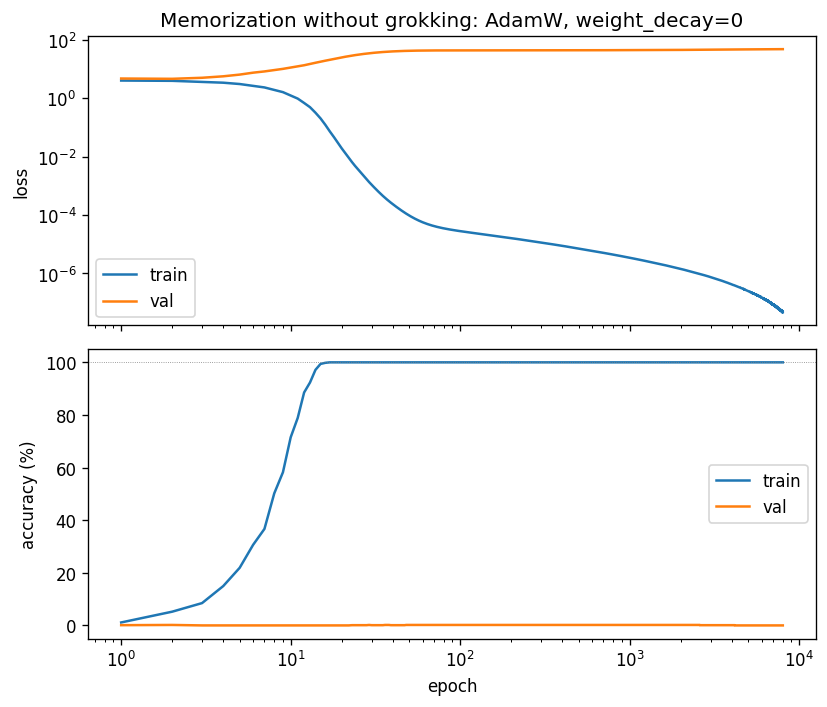

In [15]:
torch.manual_seed(0)
no_wd_model = Model(hidden_dim=128)
no_wd_opt = torch.optim.AdamW(
    no_wd_model.parameters(),
    lr=3e-2,
    weight_decay=0,
)

no_wd_history = train_model(
    no_wd_model,
    no_wd_opt,
    data,
    NUM_EPOCHS,
)

plot_history(no_wd_history, title="Memorization without grokking: AdamW, weight_decay=0")

Dla `weight_decay=3e-2` widać klasyczne zjawisko **grokkingu**: model bardzo szybko osiąga prawie **100% dokładności treningowej**, ale dokładność walidacyjna przez długi czas pozostaje bliska zeru. Dopiero po wielu epokach następuje gwałtowny skok dokładności walidacyjnej do prawie **100%**. Oznacza to, że model najpierw zapamiętuje zbiór treningowy, a dopiero dużo później zaczyna generalizować regułę dodawania modulo.

Dla `weight_decay=5` różnica między dokładnością treningową i walidacyjną jest dużo mniejsza. Dokładność treningowa rośnie pierwsza, ale dokładność walidacyjna zaczyna rosnąć niedługo później i również szybko osiąga **100%**. Nie ma więc długiego okresu, w którym model ma bardzo wysoką dokładność treningową, ale bardzo niską walidacyjną. Silniejsza regularyzacja usuwa opóźnienie grokkingu.

Silniejszy `weight_decay` działa jak mocniejsze ograniczenie na wagi modelu. Model nie może łatwo utrzymywać rozwiązania polegającego tylko na zapamiętaniu przykładów treningowych, ponieważ takie rozwiązanie zwykle wymaga bardziej złożonych lub większych wag. Zamiast tego optymalizacja szybciej kieruje model w stronę prostszego rozwiązania, które opisuje ogólną regułę:

\[
(a + b) \bmod P
\]

Dlatego przy dużym `weight_decay=5` model szybciej „rozumie” strukturę zadania, a nie tylko zapamiętuje dane.

Dla `weight_decay=0` model zapamiętuje zbiór treningowy, ale nie generalizuje. Dokładność treningowa osiąga **100%**, natomiast dokładność walidacyjna pozostaje bliska **0%** przez cały czas treningu. Strata walidacyjna rośnie, co oznacza, że model staje się coraz bardziej pewny błędnych odpowiedzi na danych walidacyjnych. Bez weight decay nie ma mechanizmu, który wypychałby model z rozwiązania memorującego w stronę prostszego rozwiązania generalizującego.

### Measuring the grokking gap

To compare runs quantitatively we define two events:
- **memorize@** — first epoch where train accuracy $\geq 99\%$.
- **grok@** — first epoch where val accuracy $\geq 90\%$.

The **grokking gap** is `grok@ - memorize@`: the number of epochs the model spends
"stuck" having memorized but not yet generalized.

### Exercise 4 — `first_epoch_reaching`
Implement a helper that returns the first epoch index at which a metric series
reaches a threshold (or `None` if it never does), then report `memorize@`,
`grok@`, and the gap for your grokking run.

In [16]:
def first_epoch_reaching(history, metric, threshold):
    """
    Return the first epoch where history[metric] >= threshold.
    Return None if the threshold is never reached.
    """
    for epoch, value in zip(history["epoch"], history[metric]):
        if value >= threshold:
            return epoch
    return None


# mem  = first_epoch_reaching(grok_history["train_acc"], 99.0)
# grok = first_epoch_reaching(grok_history["val_acc"], 90.0)
# print(f"memorize@{mem}  grok@{grok}  gap={grok - mem}")

In [17]:
memorize_at = first_epoch_reaching(grok_history, "train_acc", 99)
grok_at = first_epoch_reaching(grok_history, "val_acc", 90)

if memorize_at is None or grok_at is None:
    gap = None
else:
    gap = grok_at - memorize_at

print(f"memorize@ = {memorize_at}")
print(f"grok@     = {grok_at}")
print(f"gap       = {gap}")

memorize@ = 14
grok@     = 4208
gap       = 4194


In [18]:
def grokking_stats(history, name):
    memorize_at = first_epoch_reaching(history, "train_acc", 99)
    grok_at = first_epoch_reaching(history, "val_acc", 90)

    gap = None
    if memorize_at is not None and grok_at is not None:
        gap = grok_at - memorize_at

    print(f"{name}")
    print(f"  memorize@ = {memorize_at}")
    print(f"  grok@     = {grok_at}")
    print(f"  gap       = {gap}")
    print()


grokking_stats(grok_history, "AdamW, wd=3e-2")
grokking_stats(strong_wd_history, "AdamW, wd=5")
grokking_stats(no_wd_history, "AdamW, wd=0")

AdamW, wd=3e-2
  memorize@ = 14
  grok@     = 4208
  gap       = 4194

AdamW, wd=5
  memorize@ = 48
  grok@     = 82
  gap       = 34

AdamW, wd=0
  memorize@ = 14
  grok@     = None
  gap       = None



W zadaniu 4 zmierzono **grokking gap**, czyli liczbę epok pomiędzy momentem zapamiętania danych treningowych a momentem rozpoczęcia dobrej generalizacji.

Dla głównego eksperymentu z `AdamW, weight_decay=3e-2` otrzymano:

- `memorize@ = 14`
- `grok@ = 4208`
- `gap = 4194`

Oznacza to, że model już po **14 epokach** osiągnął co najmniej **99% dokładności treningowej**, czyli praktycznie zapamiętał zbiór treningowy. Jednak dopiero w epoce **4208** dokładność walidacyjna przekroczyła **90%**. Przez około **4194 epoki** model był więc w stanie, w którym bardzo dobrze działał na danych treningowych, ale nie generalizował na dane walidacyjne. To jest właśnie klasyczny przykład grokkingu.

Porównanie różnych wartości `weight_decay` pokazuje, jak silnie regularyzacja wpływa na ten efekt:

| konfiguracja | memorize@ | grok@ | gap |
|---|---:|---:|---:|
| AdamW, `wd=3e-2` | 14 | 4208 | 4194 |
| AdamW, `wd=5` | 48 | 82 | 34 |
| AdamW, `wd=0` | 14 | None | None |

Dla `weight_decay=5` model memoruje później niż przy `wd=3e-2`, bo silna regularyzacja utrudnia szybkie dopasowanie się do danych treningowych. Jednak generalizacja pojawia się niemal od razu po memorowaniu — luka wynosi tylko **34 epoki**. Oznacza to, że silny `weight_decay` zmusza model do znalezienia prostszego rozwiązania, które lepiej opisuje regułę dodawania modulo.

Dla `weight_decay=0` model również memoruje bardzo szybko, już w epoce **14**, ale nigdy nie osiąga progu `grok@`, czyli **90% dokładności walidacyjnej**. W tym przypadku `gap = None`, ponieważ generalizacja nie nastąpiła w czasie treningu. Brak regularyzacji pozwala modelowi pozostać przy rozwiązaniu polegającym na zapamiętaniu danych, bez przejścia do ogólnej reguły.


### Does the optimizer affect grokking?

Train the **same** model (identical initialization and data split) with several
optimizers and watch the grokking gap. To make it a fair comparison we hold weight
decay fixed at `1e-3` and tune each learning rate so that every run memorizes
within ~50 epochs — the only thing left to differ is how long weight decay then
takes to push the model from memorizing to generalizing.

A `build_optimizer` helper and a list of tuned configs are provided below.

### Exercise 5
For each config: clone the shared initial weights, build the optimizer, train, and
record the history. Then **(a)** print a table of `memorize@`, `grok@`, gap, and
final val accuracy, and **(b)** plot val accuracy vs epoch (log x-axis) for all
optimizers on one figure.

Pay attention to **AdamW with `wd=1e-3`**: its weight decay is *decoupled* from the
adaptive update, so at this nominal value it is far too weak to pull the model out
of memorization — val accuracy stays near chance and it never groks within the
horizon. Bumping it to `wd=3e-2` recovers grokking. The lesson: what drives
grokking is the *effective* amount of regularization, not the nominal
weight-decay number — and that depends on the optimizer.

In [19]:
def build_optimizer(name, params, lr, weight_decay):
    """Construct an optimizer by name; all variants accept weight decay so the
    optimizer is the only thing changing between runs."""
    name = name.lower()
    if name == "adamw":     # decoupled weight decay
        return torch.optim.AdamW(params, lr=lr, weight_decay=weight_decay)
    if name == "adam":      # L2 weight decay folded into the gradient
        return torch.optim.Adam(params, lr=lr, weight_decay=weight_decay)
    if name == "momentum":
        return torch.optim.SGD(params, lr=lr, momentum=0.9, weight_decay=weight_decay)
    if name == "sgd":
        return torch.optim.SGD(params, lr=lr, weight_decay=weight_decay)
    raise ValueError(f"unknown optimizer: {name!r}")


WD = 1e-3
CONFIGS = [
    ("SGD",             "sgd",      10.0,  WD),
    ("SGD + momentum",  "momentum",  1.0,  WD),
    ("Adam",            "adam",      1e-3, WD),
    ("AdamW (wd=1e-3)", "adamw",     3e-2, WD),
    ("AdamW (wd=3e-2)", "adamw",     3e-2, 3e-2),
]

# Shared initial weights so the optimizer is the only thing that differs.
torch.manual_seed(0)
init_state = copy.deepcopy(Model(hidden_dim=128).state_dict())

In [22]:
NUM_EPOCHS = 8000
data = make_data()

histories = {}

for label, opt_name, lr, wd in CONFIGS:
    print(f"Training {label}...")

    # Same architecture, same initial weights
    model = Model(hidden_dim=128)
    model.load_state_dict(copy.deepcopy(init_state))

    # Optimizer differs between runs
    optimizer = build_optimizer(
        opt_name,
        model.parameters(),
        lr=lr,
        weight_decay=wd,
    )

    history = train_model(
        model,
        optimizer,
        data,
        NUM_EPOCHS,
        progress=True,
    )

    histories[label] = history

Training SGD...


100%|██████████| 8000/8000 [00:30<00:00, 262.70it/s]


Training SGD + momentum...


100%|██████████| 8000/8000 [00:26<00:00, 302.51it/s]


Training Adam...


100%|██████████| 8000/8000 [00:36<00:00, 220.88it/s]


Training AdamW (wd=1e-3)...


100%|██████████| 8000/8000 [00:39<00:00, 201.19it/s]


Training AdamW (wd=3e-2)...


100%|██████████| 8000/8000 [00:38<00:00, 210.42it/s]


In [23]:
def summarize_run(history):
    memorize_at = first_epoch_reaching(history, "train_acc", 99)
    grok_at = first_epoch_reaching(history, "val_acc", 90)

    gap = None
    if memorize_at is not None and grok_at is not None:
        gap = grok_at - memorize_at

    final_val_acc = history["val_acc"][-1]

    return memorize_at, grok_at, gap, final_val_acc


print(f"{'optimizer':<20} {'memorize@':>10} {'grok@':>10} {'gap':>10} {'final val acc':>15}")
print("-" * 70)

for name, history in histories.items():
    memorize_at, grok_at, gap, final_val_acc = summarize_run(history)

    print(
        f"{name:<20} "
        f"{str(memorize_at):>10} "
        f"{str(grok_at):>10} "
        f"{str(gap):>10} "
        f"{final_val_acc:>14.2f}%"
    )

optimizer             memorize@      grok@        gap   final val acc
----------------------------------------------------------------------
SGD                          34        255        221         100.00%
SGD + momentum               32        378        346         100.00%
Adam                        139       1398       1259         100.00%
AdamW (wd=1e-3)              14       None       None           0.09%
AdamW (wd=3e-2)              14       4208       4194         100.00%


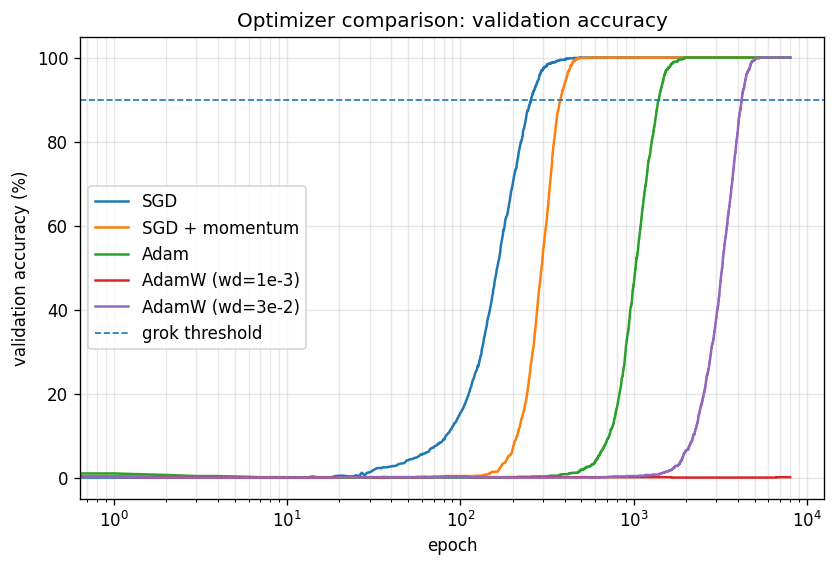

In [24]:
plt.figure(figsize=(8, 5), dpi=120)

for name, history in histories.items():
    plt.plot(
        history["epoch"],
        history["val_acc"],
        label=name,
    )

plt.xscale("log")
plt.xlabel("epoch")
plt.ylabel("validation accuracy (%)")
plt.title("Optimizer comparison: validation accuracy")
plt.axhline(90, linestyle="--", linewidth=1, label="grok threshold")
plt.legend()
plt.grid(True, which="both", alpha=0.3)
plt.show()

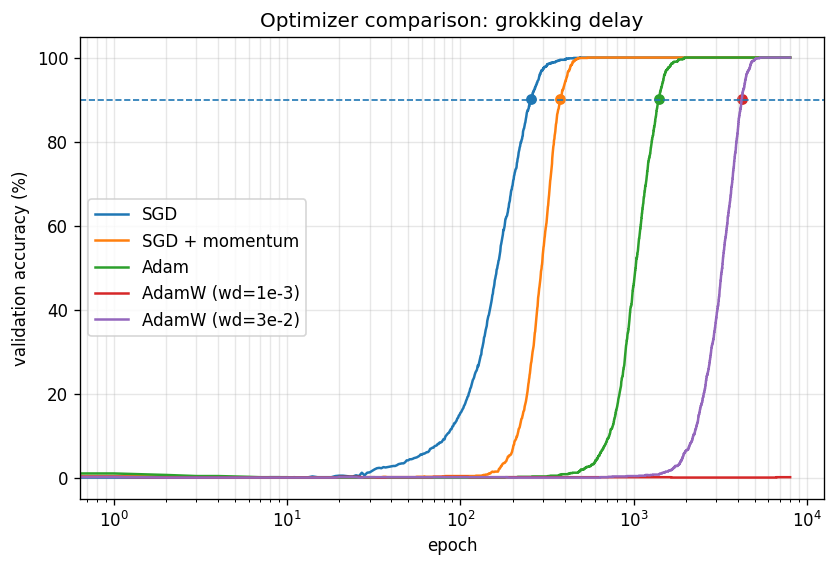

In [25]:
plt.figure(figsize=(8, 5), dpi=120)

for name, history in histories.items():
    plt.plot(history["epoch"], history["val_acc"], label=name)

    grok_at = first_epoch_reaching(history, "val_acc", 90)
    if grok_at is not None:
        grok_idx = history["epoch"].index(grok_at)
        plt.scatter(
            grok_at,
            history["val_acc"][grok_idx],
            s=30,
        )

plt.xscale("log")
plt.xlabel("epoch")
plt.ylabel("validation accuracy (%)")
plt.title("Optimizer comparison: grokking delay")
plt.axhline(90, linestyle="--", linewidth=1)
plt.legend()
plt.grid(True, which="both", alpha=0.3)
plt.show()

W tym eksperymencie porównano wpływ różnych optymalizatorów na moment wystąpienia grokkingu. Wszystkie modele startowały z tych samych wag początkowych i były trenowane na tym samym podziale danych, więc główną różnicą był sposób działania optymalizatora oraz efektywna siła regularyzacji.

Wyniki pokazują, że optymalizator ma bardzo duży wpływ na długość **grokking gap**:

| optimizer | memorize@ | grok@ | gap | final val acc |
|---|---:|---:|---:|---:|
| SGD | 34 | 255 | 221 | 100.00% |
| SGD + momentum | 32 | 378 | 346 | 100.00% |
| Adam | 139 | 1398 | 1259 | 100.00% |
| AdamW (`wd=1e-3`) | 14 | None | None | 0.09% |
| AdamW (`wd=3e-2`) | 14 | 4208 | 4194 | 100.00% |

Najkrótszy grokking gap uzyskał zwykły **SGD**. Model zapamiętał dane w epoce **34**, a zaczął dobrze generalizować w epoce **255**, więc luka wyniosła **221 epok**. Dla **SGD z momentum** zapamiętanie nastąpiło podobnie szybko, ale generalizacja pojawiła się później, w epoce **378**.

Dla **Adama** proces był wolniejszy. Model zapamiętał dane dopiero w epoce **139**, a próg generalizacji przekroczył w epoce **1398**. Luka wyniosła więc **1259 epok**, czyli znacznie więcej niż dla SGD.

Najciekawszy przypadek to **AdamW z `weight_decay=1e-3`**. Model bardzo szybko zapamiętał zbiór treningowy, już w epoce **14**, ale nie zgrokował wcale w zadanym horyzoncie treningu. Końcowa dokładność walidacyjna wyniosła tylko **0.09%**, czyli model praktycznie nie nauczył się reguły ogólnej. Oznacza to, że przy tej wartości `weight_decay` efektywna regularyzacja w AdamW była zbyt słaba, aby wypchnąć model z rozwiązania polegającego na memorowaniu.

Po zwiększeniu `weight_decay` dla AdamW do `3e-2` grokking pojawił się ponownie. Model nadal memorował bardzo szybko, w epoce **14**, ale generalizacja nastąpiła dopiero w epoce **4208**, co dało bardzo dużą lukę równą **4194 epoki**.

Na wykresie dobrze widać, że wszystkie skutecznie grokujące optymalizatory osiągają finalnie **100% accuracy walidacyjnej**, ale robią to w bardzo różnych momentach. Krzywe walidacyjne przesuwają się w prawo w kolejności: SGD, SGD + momentum, Adam, AdamW z większym weight decay. AdamW z małym `wd=1e-3` pozostaje płasko przy zerowej dokładności walidacyjnej.

Wniosek z eksperymentu jest taki, że grokking zależy nie tylko od samej wartości `weight_decay`, ale od jego **efektywnego działania w danym optymalizatorze**. Ta sama nominalna wartość `weight_decay=1e-3` może działać zupełnie inaczej w SGD, Adamie i AdamW. W szczególności w AdamW weight decay jest odłączony od adaptacyjnego kroku optymalizacji, dlatego przy małej wartości może być za słaby, aby doprowadzić model do generalizacji.

### Questions
1. Grokking is described as "delayed generalization". In terms of the train/val
   loss and accuracy curves, what *exactly* is delayed, and relative to what?
2. Weight decay is the knob here. Explain mechanistically why shrinking the weight
   norm can turn a memorizing solution into a generalizing one.
3. Is grokking specific to this MLP, or to modular addition? What would you change
   to test that?

### Recommended reading
1. Power, Burda, Edwards, Babuschkin, Misra. [Grokking: Generalization Beyond
   Overfitting on Small Algorithmic Datasets](https://arxiv.org/abs/2201.02177)
   (2022).
2. Liu, Kitouni, Nolte, et al. Towards Understanding Grokking: An Effective Theory
   of Representation Learning: [blog](https://www.neelnanda.io/grokking-paper), [paper](https://arxiv.org/abs/2205.10343) (2022).
3. Nanda, Chan, Lieberum, Smith, Steinhardt. [Progress Measures for Grokking via
   Mechanistic Interpretability](https://arxiv.org/abs/2301.05217) (2023).
4. Li, Xu, Taylor, Studer, Goldstein. [Visualizing the Loss Landscape of Neural
   Nets](https://arxiv.org/abs/1712.09913)
5. Liu, Michaud, Tegmark [Omnigrok: Grokking Beyond Algorithmic Data](https://arxiv.org/pdf/2210.01117)



#### 1. Co jest opóźnione?

Opóźniona jest **generalizacja**, czyli wzrost dokładności walidacyjnej. Model szybko osiąga prawie `100%` na treningu, ale walidacja przez długi czas pozostaje słaba. Dopiero później `val accuracy` gwałtownie rośnie.

#### 2. Dlaczego weight decay pomaga?

Weight decay zmniejsza normy wag i karze zbyt złożone rozwiązania. Dzięki temu modelowi trudniej utrzymać samo zapamiętanie przykładów. Z czasem przechodzi do prostszego rozwiązania, czyli nauczenia się reguły:

\[
(a + b) \bmod P
\]

Takie rozwiązanie działa też na danych walidacyjnych.

#### 3. Czy grokking dotyczy tylko tego MLP?

Nie. Ten eksperyment pokazuje grokking na prostym przykładzie, ale zjawisko można testować także dla innych modeli i zadań. Można zmienić architekturę, np. użyć Transformera, albo zmienić zadanie, np. na mnożenie modulo, odejmowanie modulo lub inne reguły algorytmiczne. Jeśli nadal pojawia się schemat: szybkie memorowanie, długa przerwa i późna generalizacja, to grokking nie jest specyficzny dla tego MLP ani dla dodawania modulo.